# 06 - Conditional pressure (does pressure win, by playstyle?)

**Input:** `data/processed/strokes_all.csv`, `data/processed/player_clusters_W.csv`, `data/raw/match.csv`
**What it does:** women's singles only. Builds a rally-player table (each player's mean displacement applied in a rally + whether they won + their playstyle), characterizes the sample, fits a logistic regression of rally win on standardized displacement separately within each playstyle, and produces an exploratory hitter-by-opponent style win-rate grid.
**Output:** `output/pressure_by_style.png`, `output/pressure_logit_coefs.csv`, `output/rally_sample_table.csv`, `output/hitter_opponent_winrate.csv`

Analysis type: exploratory / descriptive-inferential, **not causal**. The playstyle clusters are weak (silhouette ~0.22), so style-conditional findings are suggestive only.

In [1]:
## --- path bootstrap: run from the repo root no matter where this is launched ---
## nbconvert and some editors set the working directory to the notebook's own
## folder. Walk up until we find the repo root (the folder containing data/),
## chdir there so relative data paths resolve, and put code/ on sys.path so the
## shared modules (utils.py, shot_translations.py) import cleanly.
import os, sys
_d = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_d, "data")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
if os.path.join(_d, "code") not in sys.path:
    sys.path.insert(0, os.path.join(_d, "code"))
print("working directory:", os.getcwd())

working directory: /Users/aakankshvaidya/Desktop/qss20_final_project


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import utils

In [3]:
## CONFIG
PROC_DIR = utils.PROC_DIR
OUT_DIR = utils.OUT_DIR
os.makedirs(OUT_DIR, exist_ok=True)

## cluster-number -> human label (decided from the cluster profiles in nb 05)
STYLE_LABELS = {1: "Placement", 2: "Patient", 3: "Power"}

def fit_logit(df):
    ## logit of won ~ standardized mean_displacement; returns coef, se, p, CI
    x = (df["mean_displacement"] - df["mean_displacement"].mean()) / df["mean_displacement"].std()
    X = sm.add_constant(x)
    model = sm.Logit(df["won"], X).fit(disp=0)
    coef = model.params.iloc[1]
    se = model.bse.iloc[1]
    pval = model.pvalues.iloc[1]
    ci_low, ci_high = model.conf_int().iloc[1]
    return coef, se, pval, ci_low, ci_high

## Load, resolve names, restrict to women's, attach playstyle

In [4]:
strokes = utils.load_strokes()
matches = utils.load_matches()
clusters = pd.read_csv(os.path.join(PROC_DIR, "player_clusters_W.csv"))
print("strokes (all):", len(strokes), " women's clusters:", len(clusters), "players")

strokes = utils.map_player_names(strokes, matches)
strokes = utils.restrict_to_womens(strokes, how="clusters")

cluster_lookup = clusters.set_index("player_name")["cluster"].to_dict()
strokes["hitter_cluster"] = strokes["player_name"].map(cluster_lookup)
strokes["hitter_style"] = strokes["hitter_cluster"].map(STYLE_LABELS)

strokes (all): 52356  women's clusters: 13 players
map_player_names: rows before merge = 52356, after = 52356
map_player_names: unique players resolved = 35
restrict_to_womens: rows before filter = 52356, after = 22503


## Build the rally-player analysis table\nOne row per (rally, player): mean displacement applied, whether they won, their style.

In [5]:
valid = strokes.dropna(subset=["displacement", "hitter_won_rally", "hitter_style"]).copy()
rally_player = (
    valid.groupby(["match_id", "set_num", "rally", "player_name"])
    .agg(mean_displacement=("displacement", "mean"),
         n_shots=("displacement", "size"),
         won=("hitter_won_rally", "first"),
         style=("hitter_style", "first"))
    .reset_index()
)
rally_player["won"] = rally_player["won"].astype(int)
print("rally-player observations:", len(rally_player))
print("unique rallies:", rally_player.groupby(['match_id','set_num','rally']).ngroups)
print(rally_player["style"].value_counts())

rally-player observations: 4350
unique rallies: 2203
style
Placement    2388
Power        1067
Patient       895
Name: count, dtype: int64


## Analysis-sample characterization table (rubric: characterize the sample)

In [6]:
sample_table = rally_player.groupby("style").agg(
    n_observations=("won", "size"),
    n_players=("player_name", "nunique"),
    mean_displacement=("mean_displacement", "mean"),
    rally_win_rate=("won", "mean"),
).round(3)
print(sample_table)
sample_table.to_csv(os.path.join(OUT_DIR, "rally_sample_table.csv"))

           n_observations  n_players  mean_displacement  rally_win_rate
style                                                                  
Patient               895          2            157.467           0.479
Placement            2388          8            160.032           0.495
Power                1067          3            147.254           0.507


## Logistic regression: won ~ standardized displacement, within each style

In [7]:
rows = []
for style in ["Placement", "Patient", "Power"]:
    sub = rally_player[rally_player["style"] == style]
    coef, se, pval, ci_low, ci_high = fit_logit(sub)
    rows.append({"style": style, "n_obs": len(sub), "coef": round(coef, 4),
                 "std_err": round(se, 4), "p_value": round(pval, 4),
                 "ci_low": round(ci_low, 4), "ci_high": round(ci_high, 4)})
    sig = "  *significant*" if pval < 0.05 else ""
    print(f"{style:12s}: coef={coef:+.3f}  se={se:.3f}  p={pval:.3f}  95% CI=[{ci_low:+.3f}, {ci_high:+.3f}]{sig}")
coef_table = pd.DataFrame(rows)
coef_table.to_csv(os.path.join(OUT_DIR, "pressure_logit_coefs.csv"), index=False)

Placement   : coef=+0.026  se=0.041  p=0.530  95% CI=[-0.055, +0.106]
Patient     : coef=-0.140  se=0.068  p=0.038  95% CI=[-0.272, -0.008]  *significant*
Power       : coef=-0.088  se=0.061  p=0.151  95% CI=[-0.209, +0.032]


## Main figure: displacement effect on win odds, per style (95% CI)

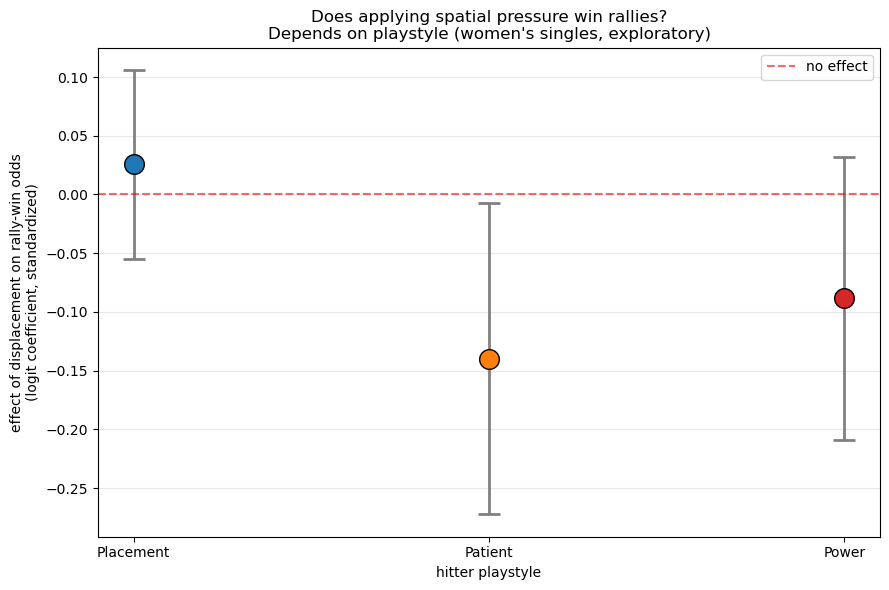

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
styles = coef_table["style"]; coefs = coef_table["coef"]
ci_low = coef_table["ci_low"]; ci_high = coef_table["ci_high"]
yerr = [coefs - ci_low, ci_high - coefs]
colors = ["#1f77b4", "#ff7f0e", "#d62728"]
ax.errorbar(styles, coefs, yerr=yerr, fmt="o", markersize=12, capsize=8, capthick=2,
            linewidth=2, color="black", ecolor="gray")
for i, c in enumerate(coefs):
    ax.scatter(i, c, s=200, c=colors[i], zorder=5, edgecolor="black")
ax.axhline(0, color="red", linestyle="--", alpha=0.6, label="no effect")
ax.set_ylabel("effect of displacement on rally-win odds\n(logit coefficient, standardized)")
ax.set_xlabel("hitter playstyle")
ax.set_title("Does applying spatial pressure win rallies?\nDepends on playstyle (women's singles, exploratory)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pressure_by_style.png"), dpi=150)
plt.show()

## Secondary (exploratory): hitter x opponent style win-rate grid\nSmall cells; interpret with caution.

In [9]:
rally_styles = (
    rally_player.groupby(["match_id", "set_num", "rally"])["style"]
    .apply(list).reset_index(name="styles_in_rally")
)
rp = rally_player.merge(rally_styles, on=["match_id", "set_num", "rally"], how="left")

def get_opponent_style(row):
    others = [s for s in row["styles_in_rally"] if s != row["style"]]
    return row["style"] if len(others) == 0 else others[0]

rp["opponent_style"] = rp.apply(get_opponent_style, axis=1)
grid = rp.pivot_table(index="style", columns="opponent_style", values="won", aggfunc="mean").round(3)
grid_n = rp.pivot_table(index="style", columns="opponent_style", values="won", aggfunc="size")
print("win rate (hitter x opponent):"); print(grid)
print("\ncell sample sizes:"); print(grid_n)
grid.to_csv(os.path.join(OUT_DIR, "hitter_opponent_winrate.csv"))

win rate (hitter x opponent):
opponent_style  Patient  Placement  Power
style                                    
Patient           0.000      0.449  0.504
Placement         0.547      0.492  0.452
Power             0.494      0.548  0.498

cell sample sizes:
opponent_style  Patient  Placement  Power
style                                    
Patient              13        285    597
Placement           285       1862    241
Power               597        241    229
